In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving PakistanFloodsDataset.csv to PakistanFloodsDataset.csv
User uploaded file "PakistanFloodsDataset.csv" with length 14552251 bytes


In [4]:
df = pd.read_csv("PakistanFloodsDataset.csv")
df.head()

,year,month,temperature_c,max_temperature_c,min_temperature_c,relative_humidity_percent,wind_speed_mps,rainfall_mm
0,1981,1,18.92,27.76,12.47,48.36,1.65,0.00
1,1981,1,19.71,28.75,12.44,42.58,2.39,0.00
2,1981,1,18.60,26.95,12.86,46.74,1.77,0.00
3,1981,1,20.05,29.51,12.46,50.47,2.51,0.17
4,1981,1,17.28,23.94,10.95,48.31,1.29,0.01


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365574 entries, 0 to 365573
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   year                       365574 non-null  int64  
 1   month                      365574 non-null  int64  
 2   temperature_c              365574 non-null  float64
 3   max_temperature_c          365574 non-null  float64
 4   min_temperature_c          365574 non-null  float64
 5   relative_humidity_percent  365574 non-null  float64
 6   wind_speed_mps             365574 non-null  float64
 7   rainfall_mm                365574 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 22.3 MB


In [6]:
df.shape

(365574, 8)

In [7]:
print(df.isnull().sum())

year                         0
month                        0
temperature_c                0
max_temperature_c            0
min_temperature_c            0
relative_humidity_percent    0
wind_speed_mps               0
rainfall_mm                  0
dtype: int64


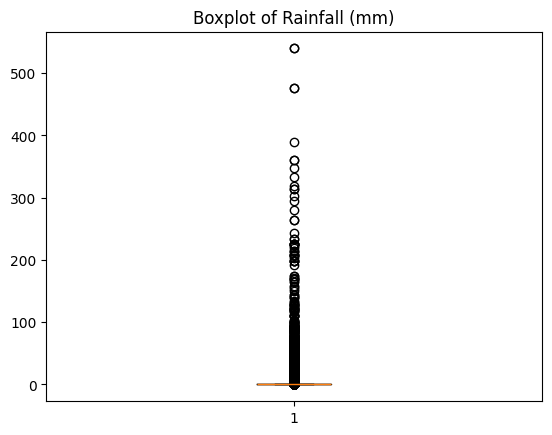

In [8]:
plt.boxplot(df["rainfall_mm"])
plt.title("Boxplot of Rainfall (mm)")
plt.show()

In [9]:
X = df.drop("rainfall_mm", axis=1)
y = df["rainfall_mm"]

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

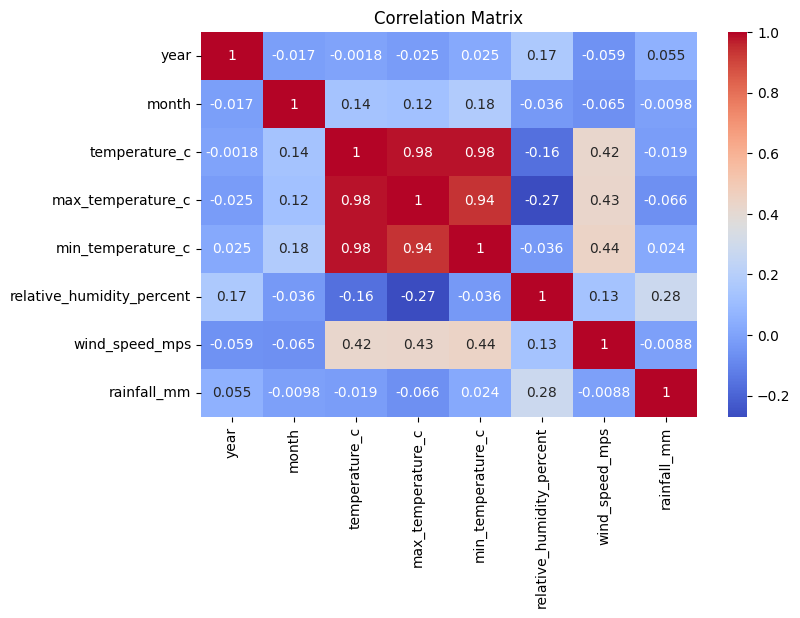

In [12]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

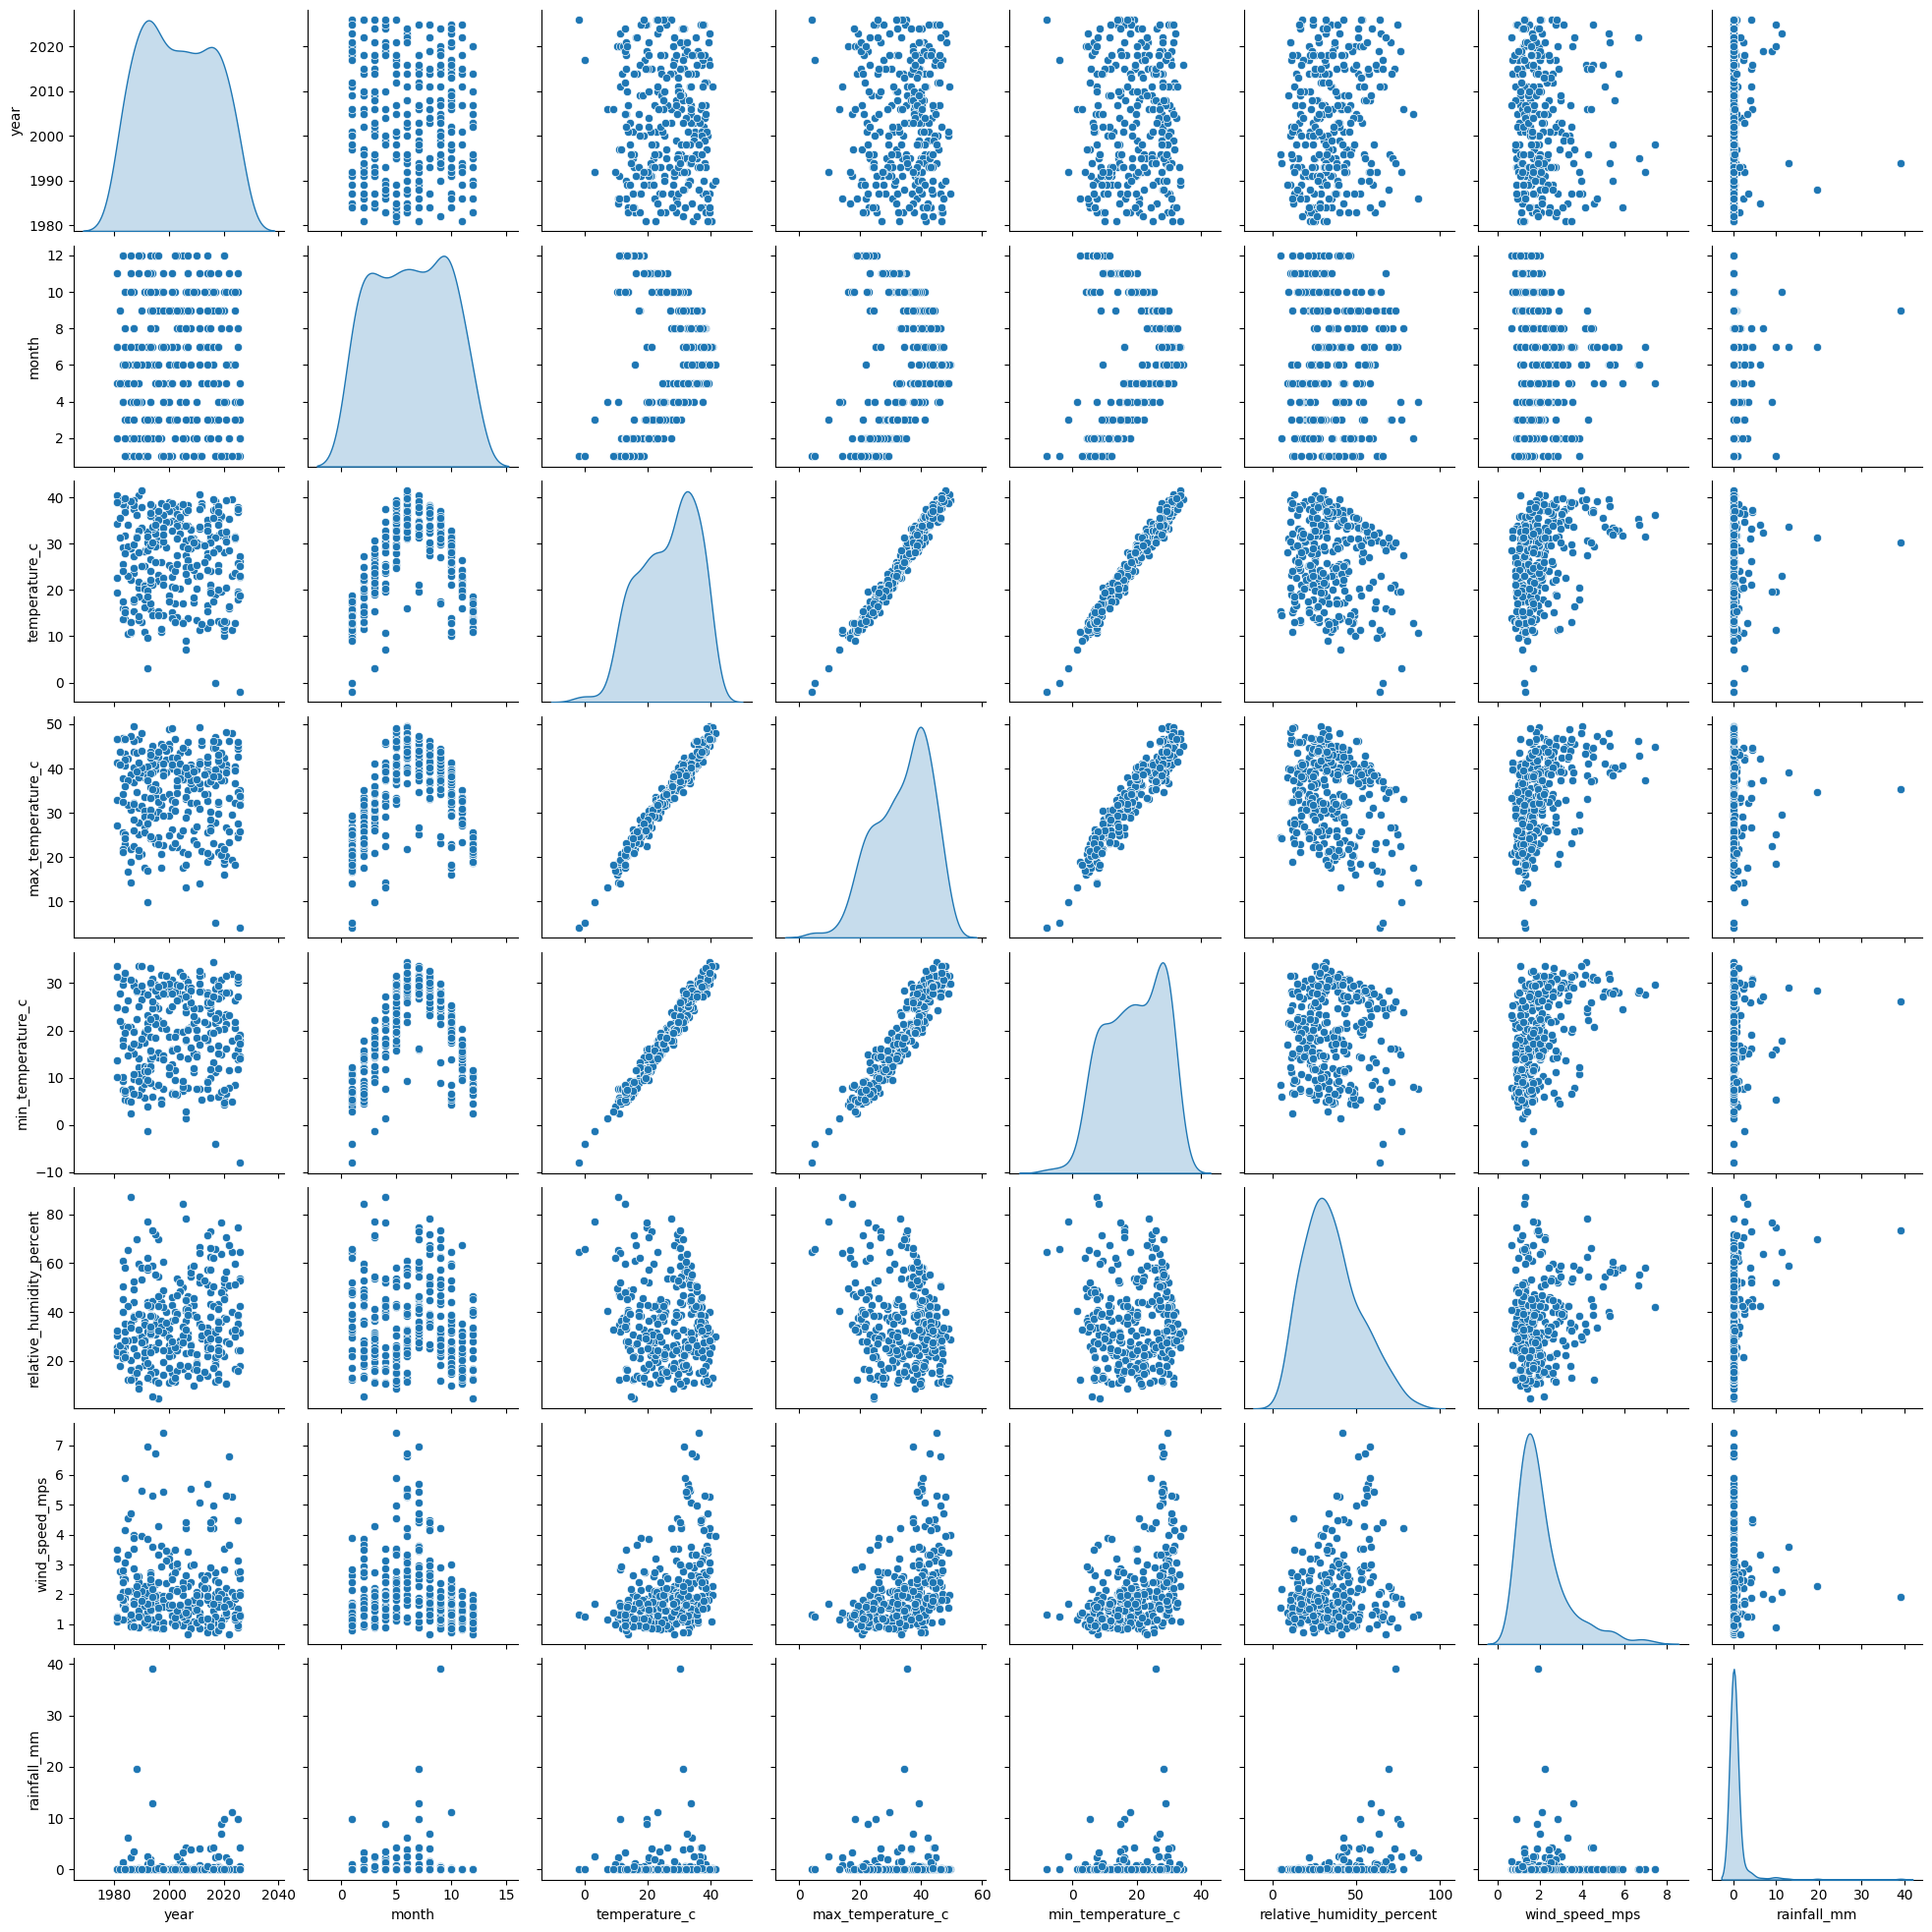

In [14]:
sns.pairplot(df.sample(300), diag_kind='kde')
plt.show()

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
def predict_rainfall():
    print("\nEnter the weather features to predict rainfall:")

    year = int(input("Year (e.g., 2010–2023): "))
    month = int(input("Month (1–12): "))
    temperature = float(input("Mean Temperature (°C): "))
    max_temperature = float(input("Max Temperature (°C): "))
    min_temperature = float(input("Min Temperature (°C): "))
    humidity = float(input("Relative Humidity (%): "))
    wind_speed = float(input("Wind Speed (m/s): "))

    user_input = pd.DataFrame([[
        year, month, temperature, max_temperature, min_temperature, humidity, wind_speed
    ]], columns=X.columns)

    # Scale input features
    user_scaled = scaler.transform(user_input)

    # Predict rainfall
    predicted_rainfall = model.predict(user_scaled)[0]

    print(f"\n🧾 Predicted Rainfall: {predicted_rainfall:,.2f} mm")

# 7. Call the prediction function
predict_rainfall()


Enter the weather features to predict rainfall:
Year (e.g., 2010–2023): 2022
Month (1–12): 8
Mean Temperature (°C): 32
Max Temperature (°C): 38
Min Temperature (°C): 27
Relative Humidity (%): 75
Wind Speed (m/s): 3.5

🧾 Predicted Rainfall: 3.78 mm


In [18]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

MSE: 19.838211113786887
R^2 Score: 0.10699137135953196


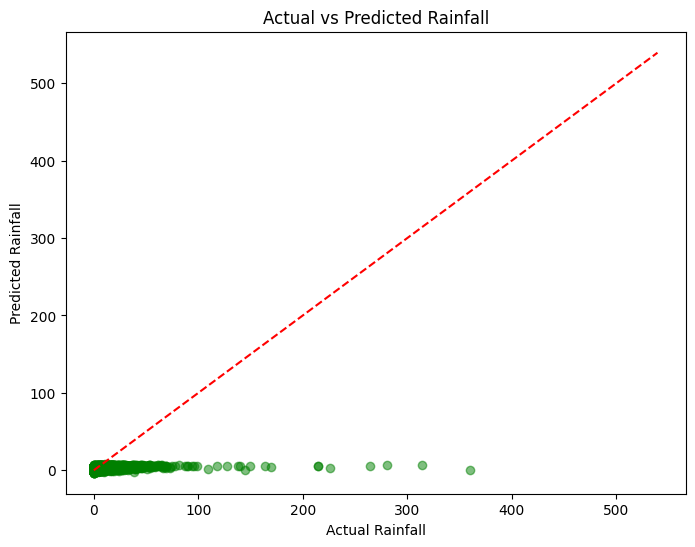

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha = 0.5,  color='green')
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted Rainfall")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r')
plt.show()